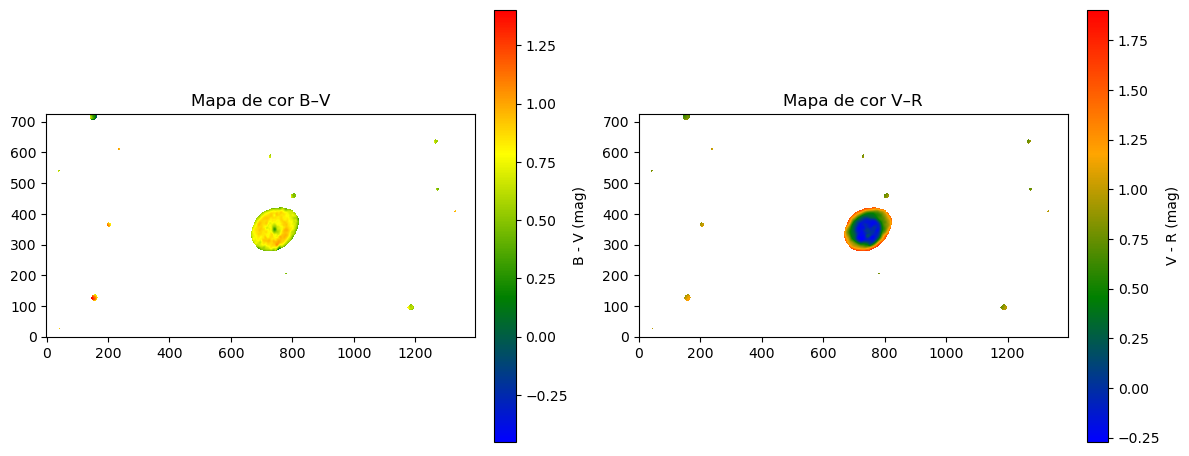

In [31]:
import numpy as np
from astropy.io import fits
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- 1) Ficheiros FITS, tempos de exposição e zero points ---
fits_files = {
    "B": "m57_blue_bkg/m57_blue_bkg.fits",
    "V": "m57_green_bkg/m57_green_bkg.fits",
    "R": "m57_red_bkg/m57_red_bkg.fits"
}

EXPTIME = {"B": 30.0, "V": 30.0, "R": 30.0}
ZP = {"B": 19.63, "V": 20.45, "R": 20.20}

# --- 2) Carregar imagens e normalizar por tempo de exposição ---
flux = {}
for band, fname in fits_files.items():
    data = fits.getdata(fname).astype(float)
    flux[band] = data / EXPTIME[band]

# --- 3) Suavizar ligeiramente ---
sigma_smooth = 3.0
for band in flux:
    flux[band] = gaussian_filter(flux[band], sigma=sigma_smooth)

# --- 4) Criar máscara ---
bg_region = (slice(0,100), slice(300,400))
mask = (flux["B"] > 0.01 * np.nanmax(flux["B"])) & \
       (flux["V"] > 0.01 * np.nanmax(flux["V"])) & \
       (flux["R"] > 0.01 * np.nanmax(flux["R"]))

# --- 5) Calcular mapas de cor ---
eps = 1e-12
BV_map = -2.5 * np.log10(np.maximum(flux["B"], eps) / np.maximum(flux["V"], eps)) + (ZP["B"] - ZP["V"])
VR_map = -2.5 * np.log10(np.maximum(flux["V"], eps) / np.maximum(flux["R"], eps)) + (ZP["V"] - ZP["R"])

BV_map_masked = np.where(mask, BV_map, np.nan)
VR_map_masked = np.where(mask, VR_map, np.nan)

# --- 6) Limites ---
bv_min, bv_max = np.nanpercentile(BV_map_masked, [0.1, 99.9])
vr_min, vr_max = np.nanpercentile(VR_map_masked, [0.1, 99.9])

# --- 7) Colormaps personalizados ---
# B–V: de azul (mais quente) → verde → amarelo → vermelho (mais frio)
cmap_BV = LinearSegmentedColormap.from_list("BV_cmap", ["blue", "green", "yellow", "red"])

# V–R: de azul → verde → laranja → vermelho (térmico)
cmap_VR = LinearSegmentedColormap.from_list("VR_cmap", ["blue", "green", "orange", "red"])

# --- 8) Plot lado a lado ---
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# B–V
im1 = axs[0].imshow(BV_map_masked, origin='lower', cmap=cmap_BV, vmin=bv_min, vmax=bv_max)
axs[0].set_title("Mapa de cor B–V")
plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, label="B - V (mag)")

# V–R
im2 = axs[1].imshow(VR_map_masked, origin='lower', cmap=cmap_VR, vmin=vr_min, vmax=vr_max)
axs[1].set_title("Mapa de cor V–R")
plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04, label="V - R (mag)")

plt.tight_layout()
plt.show()

# --- 9) Guardar FITS ---
fits.writeto("BV_map.fits", BV_map_masked, overwrite=True)
fits.writeto("VR_map.fits", VR_map_masked, overwrite=True)


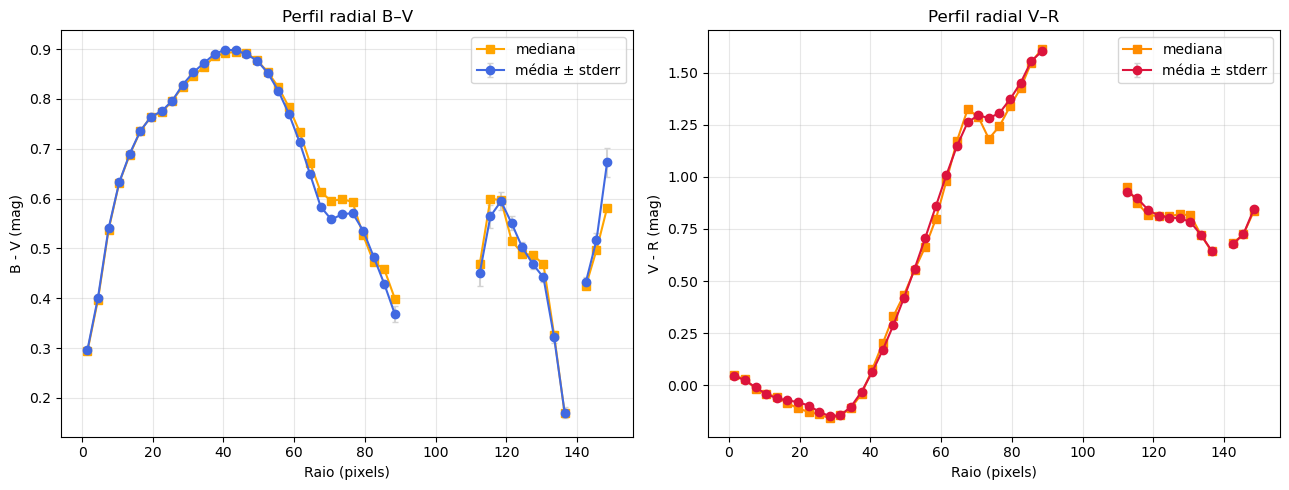

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --- Centro da nebulosa ---
x0, y0 = 744, 350

# --- Distância ao centro ---
yy, xx = np.indices(BV_map_masked.shape)
r = np.sqrt((xx - x0)**2 + (yy - y0)**2)

# --- Função auxiliar para calcular perfil radial ---
def radial_profile(map_masked, r, max_radius=150, nbins=50):
    r_flat = r.ravel()
    vals = map_masked.ravel()
    valid = ~np.isnan(vals)
    r_valid = r_flat[valid]
    vals_valid = vals[valid]

    # Limitar raio máximo
    in_radius = r_valid <= max_radius
    r_valid = r_valid[in_radius]
    vals_valid = vals_valid[in_radius]

    # Bins
    bins = np.linspace(0, max_radius, nbins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    mean, median, std, count = [], [], [], []
    for i in range(nbins):
        in_bin = (r_valid >= bins[i]) & (r_valid < bins[i+1])
        if np.any(in_bin):
            v = vals_valid[in_bin]
            mean.append(np.nanmean(v))
            median.append(np.nanmedian(v))
            std.append(np.nanstd(v))
            count.append(v.size)
        else:
            mean.append(np.nan)
            median.append(np.nan)
            std.append(np.nan)
            count.append(0)

    mean, median, std, count = map(np.array, (mean, median, std, count))
    stderr = std / np.sqrt(np.maximum(count, 1))
    return centers, mean, median, stderr

# --- Calcular perfis para B–V e V–R ---
bv_r, bv_mean, bv_median, bv_err = radial_profile(BV_map_masked, r)
vr_r, vr_mean, vr_median, vr_err = radial_profile(VR_map_masked, r)

# --- Plot lado a lado ---
fig, axs = plt.subplots(1, 2, figsize=(13,5), sharex=True, sharey=False)

# B–V
axs[0].errorbar(bv_r, bv_mean, yerr=bv_err, fmt='o-', color='royalblue', ecolor='lightgray', capsize=2, label='média ± stderr')
axs[0].plot(bv_r, bv_median, 's-', color='orange', label='mediana')
axs[0].set_xlabel('Raio (pixels)')
axs[0].set_ylabel('B - V (mag)')
axs[0].set_title('Perfil radial B–V')
axs[0].grid(alpha=0.3)
axs[0].legend()

# V–R
axs[1].errorbar(vr_r, vr_mean, yerr=vr_err, fmt='o-', color='crimson', ecolor='lightgray', capsize=2, label='média ± stderr')
axs[1].plot(vr_r, vr_median, 's-', color='darkorange', label='mediana')
axs[1].set_xlabel('Raio (pixels)')
axs[1].set_ylabel('V - R (mag)')
axs[1].set_title('Perfil radial V–R')
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()
